In [72]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
sns.set()

<center>
<h1>Étude d'un mouvement et de l'évolution des différentes formes de l'énergie à l'aide de Python</h1>
</center>
<hr />

> L'objectif de ce document est d'étudier le mouvement filmé d'une balle et d'établir l'évolution des différentes formes d'energies.

## 1. Partie expérimentale

- Charger la vidéo, nommée `BallTossUp.mov` et située dans le dossier contenant ce notebook, dans le logiciel [Mecachrono](https://www.eleves.online/MecaChrono/index.php?A=5&B=0&C=0&D=15&E=16&H=-1823542497&lang=fr).
- Sélectionner « Nombre d'images par seconde de la vidéo : 30 » et « Nombre d'images entre deux échantillonnages : 1 ».
- Placer l'origine et le repère à un endroit qui vous semblera opportun (on peut aussi ne pas modifier sa position).
- Définir l'échelle en utilisant la règle à l'écran : **chaque segment vertical jaune mesure 10 cm de long. En selectionner 10.**
- Cliquer sur les différentes positions de la balle.
- Sélectionner l'onglet « Tableau de valeurs » et exporter les données sous une forme directement exploitable sous Python.

## 2. Exploitation

### 2.1. Évolution de l'altitude au cours du temps

1. Insérer les listes contenant les dates $t$ et les valeurs des coordonnées $x$ et $y$.

In [73]:
t = [ 0, 0.0333333, 0.0666666, 0.0999999, 0.133333, 0.166667, 0.2, 0.233333, 0.266666, 0.3, 0.333333, 0.366666, 0.4, 0.433333, 0.466666, 0.5, 0.533333, 0.566666, 0.599999, 0.633333, 0.666666, 0.7, 0.733333, 0.766667, 0.8, 0.833333]
y = [0, 0.131579, 0.248684, 0.353947, 0.447368, 0.530263, 0.601316, 0.661842, 0.713158, 0.751316, 0.777632, 0.792105, 0.801316, 0.794737, 0.782895, 0.761842, 0.721053, 0.672368, 0.615789, 0.546053, 0.469737, 0.380263, 0.280263, 0.172368, 0.0513158, -0.0789474]

2. On cherche à tracer l'évolution de la coordonnée verticale $y$ en fonction du temps $t$.    
Compléter le code suivant.

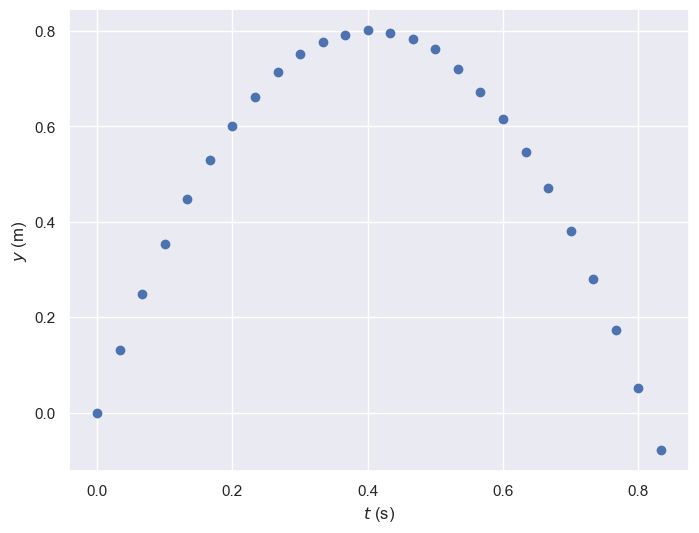

In [74]:
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(t, y, 'o')
plt.xlabel("$t$ (s)")
plt.ylabel("$y$ (m)")
plt.show()

3. Le mouvement vertical est-il : uniforme ? accéléré ? nul ?      
Justifier la réponse.

### 2.2 Modélisation de l'évolution de l'altitude au cours du temps

> Dans la suite de ce document on va être amené à dériver la fonction $y(t)$ afin de déterminer la composante verticale du vecteur vitesse $\vec{v}$. *Comme la dérivation numérique est une opération qui introduit du « bruit »*, il est préférable de **modéliser** au préalable cette fonction.

4. Compléter le code de la fonction `modele_y` suivante en fonction du comportement global de la fonction $y(t)$ constaté lors des questions précédentes.

In [75]:
# Fonction modèle pour le comportement de y en fonction de t
def modele_y(x, a, b, c):
    return a * x**2 + b * x + c

# Détermination des paramètres optimaux pour y en fonction de t
popt, pcov = curve_fit(modele_y, t, y)
a_ymod = popt[0]
b_ymod = popt[1]
c_ymod = popt[2]

# Nouvelles dates pour l'affichage des grandeurs modélisées
t_mod = np.linspace(min(t), max(t), 101)

# Valeurs de y modélisées
y_mod = modele_y(t_mod, a_ymod, b_ymod, c_ymod)

5. Compléter le code suivant, l'objectif est d'afficher $y(t)$ et $y_{mod}(t_{mod})$ afin de vérifier la pertinence de la modélisation.

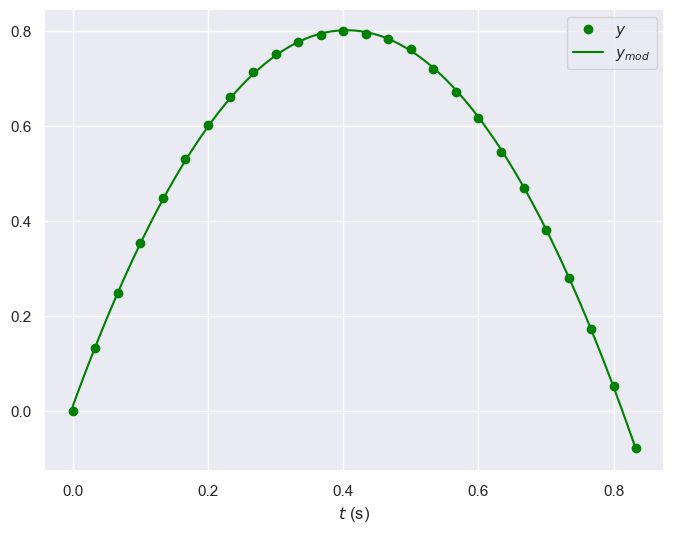

In [76]:
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(t, y, 'o', label="$y$", color="green")
plt.plot(t_mod, y_mod, '-', label="$y_{mod}$", color="green")
plt.xlabel("$t$ (s)")
plt.legend()
plt.show()

6. Le mouvement de la balle est-il une chute libre ?

> Dans la suite de ce document, on effectuera le calcul de toutes les grandeurs à partir des fonctions $y_{mod}(t_{mod})$.

### 2.3 Construction de la composante verticale de la vitesse

7. Compléter le code suivant et répondre aux questions, l'objectif étant de construire la composante $v_y$ du vecteur vitesse $\vec{v}$.

In [77]:
vy = [0] * len(t_mod)  # Liste de 0 (autant que de valeurs de t_mod)

for i in range(1, len(t_mod) - 1):   # Pourquoi cet intervalle ?
    vy[i] = (y_mod[i + 1] - y_mod[i - 1]) / (t_mod[i + 1] - t_mod[i - 1]) 

8. Compléter le code suivant. L'objectif est de tracer l'évolution au cours du temps de la composante $v_y$ du vecteur vitesse.

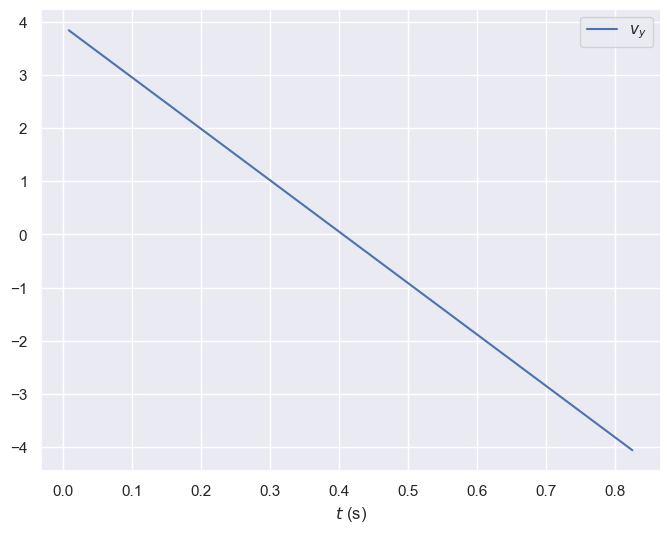

In [78]:
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(t_mod[1: -1], vy[1: -1], '-', label="$v_y$")
plt.xlabel("$t$ (s)")
plt.legend()
plt.show()

### 2.4. Construction des différentes formes d'énergies

9. Compléter le code suivant. L'objectif est de construire la grandeur énergie cinétique massique (puisqu'on n'a pas la masse de la balle).

In [79]:
Ec = [0] * len(t_mod)  # Liste de 0 (autant que de valeurs de t_mod)

for i in range(1, len(t_mod - 1)):   # Pourquoi cet intervalle ?
    Ec[i] = 0.5 * vy[i] * vy[i] 

10. Compléter le code suivant, l'objectif est de construire la grandeur énergie potentielle de pesanteur massique (puisqu'on n'a pas la masse de la balle).    
L'énergie potentielle de pesanteur est considérée nulle lorsque $y = 0$.

In [80]:
Epp = [0] * len(t_mod) # Liste de 0 (autant que de valeurs de t_mod)
g = 10   # N/kg

for i in range(1, len(t_mod) - 1):   # Pourquoi cet intervalle ?
    Epp[i] =  g * y_mod[i] 

11. Compléter le code suivant, l'objectif est de construire la grandeur énergie mécanique massique (puisqu'on n'a pas la masse de la balle).

In [81]:
Em = [0] * len(t_mod)  # Liste de 0 (autant que de valeurs de t_mod)

for i in range( 1, len(t_mod) -1 ):   # Pourquoi cet intervalle ?
    Em[i] = Ec[i] + Epp[i] 

12. Compléter le code suivant. L'objectif est de tracer l'évolution au cours du temps de toutes les formes d'énergie.

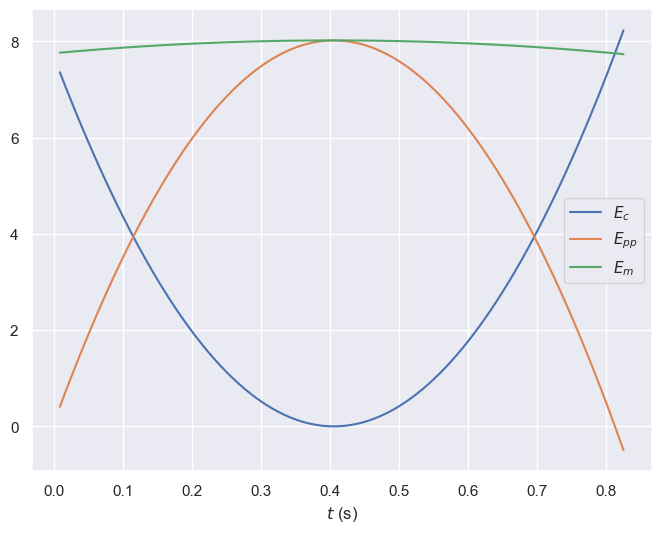

In [82]:
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(t_mod[1: -1], Ec[1: -1], '-', label="$E_c$")
plt.plot(t_mod[1: -1], Epp[1: -1], '-', label="$E_{pp}$")
plt.plot(t_mod[1: -1], Em[1: -1], '-', label="$E_m$")
plt.xlabel("$t$ (s)")
plt.legend()
plt.show()

13. Commenter l'évolution des différentes formes d'énergie.